# Case-Based Reasoning (CBR) Research

Notebook ini mengimplementasikan sistem **Case-Based Reasoning (CBR)** untuk klasifikasi diagnosis sakit kepala.

## Alur Kerja
1. **Import Library** — Memuat semua pustaka yang diperlukan
2. **Konfigurasi Path** — Mendefinisikan path dataset secara lokal
3. **Load Dataset** — Membaca dan mengeksplorasi dataset
4. **Eksplorasi Data (EDA)** — Missing values, statistik deskriptif, distribusi label
5. **Pembangunan Kamus Kode Kasus** — Memetakan kode kasus ↔ gejala
6. **Encoding Fitur** — One-hot encoding kode kasus
7. **Augmentasi Data** — Random Deletion untuk memperbanyak data
8. **Pemodelan SVM (Data Augmented)** — Training + evaluasi SVM
9. **Pemodelan SVM (Data Asli)** — Baseline SVM tanpa augmentasi
10. **Perbandingan SVM** — Sebelum vs sesudah augmentasi
11. **CBR — Representasi Basis Kasus** — TF-IDF dari data augmented
12. **CBR — Fungsi Inti** — Retrieve, Reuse, Predict
13. **CBR — Demo Query** — Contoh penggunaan nyata
14. **CBR — Evaluasi LOO-CV** — Leave-One-Out Cross-Validation
15. **CBR vs SVM** — Perbandingan performa
16. **CBR — Fase Retain** — Menyimpan kasus baru ke basis kasus
17. **Testing SVM** — Prediksi kasus testing dengan SVM (data augmented)
18. **Testing CBR** — Prediksi kasus testing dengan CBR Cosine Similarity
19. **Perbandingan Testing** — Perbandingan akhir SVM vs CBR pada data testing
20. **Ekspor Hasil Testing** — Menyimpan hasil prediksi ke file hasil_testing.csv
---

## Langkah 1: Import Library

Mengimpor semua pustaka Python yang dibutuhkan untuk analisis data, pemodelan, dan visualisasi.

In [1]:
import os
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import vstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


## Langkah 2: Konfigurasi Path Dataset

Mendefinisikan path ke file dataset secara dinamis berdasarkan lokasi notebook ini.

In [2]:
# --- Konfigurasi Path ---
# Path direktori dataset relatif terhadap lokasi notebook ini
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
DATASET_DIR  = os.path.join(NOTEBOOK_DIR, '..', 'Dataset')

# Path file-file dataset
PATH_DATASET_UTAMA     = os.path.join(DATASET_DIR, 'dataset.xlsx')
PATH_DATASET_AUGMENTED = os.path.join(DATASET_DIR, 'dataset_augmented.xlsx')
PATH_HASIL_TESTING   = os.path.join(DATASET_DIR, 'hasil_testing.csv')

# Tampilkan path untuk verifikasi
print(f"Direktori Dataset : {os.path.abspath(DATASET_DIR)}")
print(f"Dataset Utama     : {os.path.abspath(PATH_DATASET_UTAMA)}")
print(f"Dataset Augmented : {os.path.abspath(PATH_DATASET_AUGMENTED)}")

# Cek keberadaan file
print("\n--- Status File ---")
print(f"  dataset.xlsx          : {'DITEMUKAN ✓' if os.path.exists(PATH_DATASET_UTAMA) else 'TIDAK DITEMUKAN ✗'}")
print(f"  dataset_augmented.xlsx: {'DITEMUKAN ✓' if os.path.exists(PATH_DATASET_AUGMENTED) else 'BELUM ADA (akan dibuat)'}")
print(f"  hasil_testing.csv     : {'DITEMUKAN ✓' if os.path.exists(PATH_HASIL_TESTING) else 'BELUM ADA (akan dibuat)'}")

Direktori Dataset : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset
Dataset Utama     : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset\dataset.xlsx
Dataset Augmented : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset\dataset_augmented.xlsx

--- Status File ---
  dataset.xlsx          : DITEMUKAN ✓
  dataset_augmented.xlsx: DITEMUKAN ✓
  hasil_testing.csv     : DITEMUKAN ✓


## Langkah 3: Load Dataset

Membaca dataset utama dari file Excel. Dataset berisi kasus pasien dengan gejala yang telah dinormalisasi dan kode diagnosis ICD-X.

In [3]:
# Membaca dataset utama (header ada di baris ke-2, sehingga header=1)
print(f"Membaca file: {PATH_DATASET_UTAMA}")
df = pd.read_excel(PATH_DATASET_UTAMA, header=1)
df.columns = df.columns.str.strip()  # Bersihkan spasi di nama kolom

print(f"\nDataset berhasil dimuat.")
print(f"Jumlah baris   : {len(df)}")
print(f"Jumlah kolom   : {len(df.columns)}")
print(f"Nama kolom     : {list(df.columns)}")

print("\n--- 5 Data Pertama ---")
display(df.head())

Membaca file: c:\Users\admin\Documents\Penelitian\CBR Research\Program\..\Dataset\dataset.xlsx

Dataset berhasil dimuat.
Jumlah baris   : 40
Jumlah kolom   : 7
Nama kolom     : ['no', 'case_id', 'no_raw', 'icd_x', 'raw_semicolon', 'normalized_semicolon', 'case_codes']

--- 5 Data Pertama ---


,no,case_id,no_raw,icd_x,raw_semicolon,normalized_semicolon,case_codes
0,1,29,36,G44.0,sering pusing (+);sering tidak fokus(+);tiba2 ...,sering pusing;sering tidak fokus;tiba tiba ser...,"G31,O,O,O,G32,O,T"
1,2,11,17,G44.0,demam 3 hr;pusing(+);bab lembek(+);perut mual(...,demam 3 hari;pusing;bab lembek;perut mual nihi...,"O,G0,O,XG61,XG62,T"
2,3,28,35,G44.0,konsultasi rujukan Poli Saraf RSHermina pasien...,konsultasi rujukan Poli Saraf RS Hermina pasie...,G0
3,4,26,32,G44.0,Sakit kepala kiri (+);Nyeri badan sebelah kiri...,sakit kepala kiri;nyeri badan sebelah kiri tan...,"G23,O,G23,O,T,T,G614"
4,5,22,28,G44.0,kepala masih sering;terasa pusing + berputar +...,kepala masih sering;terasa pusing berputar;mua...,"G34,O,XG61,XG62,T"


## Langkah 4: Eksplorasi Data (EDA)

Memeriksa kualitas dan karakteristik dataset:
- Missing values
- Statistik deskriptif
- Distribusi label diagnosis

In [4]:
# 4.1 Cek Missing Values
print("=== Missing Values per Kolom ===")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

=== Missing Values per Kolom ===
no                      0
case_id                 0
no_raw                  0
icd_x                   0
raw_semicolon           0
normalized_semicolon    0
case_codes              0
dtype: int64

Total missing values: 0


In [5]:
# 4.2 Statistik Deskriptif (kolom numerik)
print("=== Statistik Deskriptif ===")
display(df.describe())

=== Statistik Deskriptif ===


,no,case_id,no_raw
count,40.000000,40.000000,40.000000
mean,20.500000,33.200000,22.100000
std,11.690452,20.880859,11.194779
min,1.000000,1.000000,2.000000
25%,10.750000,13.750000,13.750000
50%,20.500000,31.500000,24.000000
75%,30.250000,54.250000,32.000000
max,40.000000,65.000000,38.000000


In [6]:
# 4.3 Tampilkan kolom kunci (diagnosis, gejala, dan kode kasus)
print("=== Kolom Kunci: icd_x, normalized_semicolon, case_codes ===")
pd.set_option('display.max_columns', None)
display(df[['icd_x', 'normalized_semicolon', 'case_codes']])

=== Kolom Kunci: icd_x, normalized_semicolon, case_codes ===


,icd_x,normalized_semicolon,case_codes
0,G44.0,sering pusing;sering tidak fokus;tiba tiba ser...,"G31,O,O,O,G32,O,T"
1,G44.0,demam 3 hari;pusing;bab lembek;perut mual nihi...,"O,G0,O,XG61,XG62,T"
2,G44.0,konsultasi rujukan Poli Saraf RS Hermina pasie...,G0
3,G44.0,sakit kepala kiri;nyeri badan sebelah kiri tan...,"G23,O,G23,O,T,T,G614"
4,G44.0,kepala masih sering;terasa pusing berputar;mua...,"G34,O,XG61,XG62,T"
5,G44.0,demam sejak semalam;nyeri kepala;mual nihil;al...,"O,G0,XG61,T"
6,G44.0,kemarin;hari ini febris tadi malam;pusing;mual...,"G52,O,G0,XG61,O,XG612,O,O,O,O"
7,G44.0,pusing bagian depan kepala;demam 1 minggu;mual...,"G21,O,G61,O"
8,G44.0,pusing;mual;riwayat iritasi otak,"G0,G61,O"
9,G44.0,nyeri kepala;mual nihil;alergi obat nihil,"G0,XG61,T"


=== Distribusi Label Diagnosis (icd_x) ===
icd_x
G44.0    20
G44.2    20
Name: count, dtype: int64


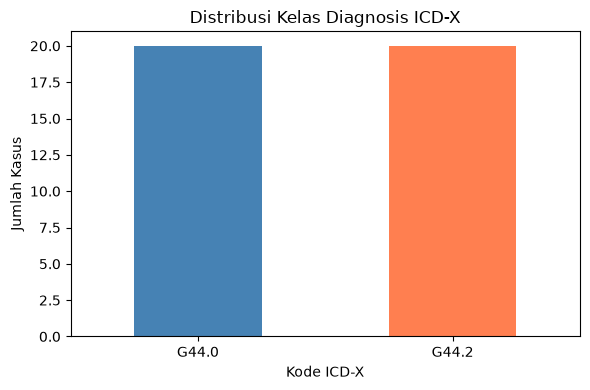

In [7]:
# 4.4 Distribusi label diagnosis (icd_x)
print("=== Distribusi Label Diagnosis (icd_x) ===")
label_counts = df['icd_x'].value_counts()
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribusi Kelas Diagnosis ICD-X')
plt.xlabel('Kode ICD-X')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Langkah 5: Pembangunan Kamus Kode Kasus ↔ Gejala

Membangun dua kamus yang saling terkait:
1. **`symptom_to_case_codes`** — Dari setiap gejala, kode kasus apa saja yang dikaitkan
2. **`case_code_to_symptoms`** — Dari setiap kode kasus, gejala apa saja yang muncul

Ini adalah inti dari representasi kasus dalam sistem CBR.

In [8]:
# --- Bangun kamus: Gejala → Kode Kasus ---
symptom_to_case_codes = {}

for _, row in df.iterrows():
    symptoms   = [s.strip() for s in row['normalized_semicolon'].split(';')] if pd.notna(row['normalized_semicolon']) else []
    case_codes = [c.strip() for c in row['case_codes'].split(',')]           if pd.notna(row['case_codes'])           else []

    for symptom in symptoms:
        if symptom not in symptom_to_case_codes:
            symptom_to_case_codes[symptom] = Counter()
        symptom_to_case_codes[symptom].update(case_codes)

# --- Bangun kamus: Kode Kasus → Gejala ---
case_code_to_symptoms = {}

for _, row in df.iterrows():
    symptoms   = [s.strip() for s in row['normalized_semicolon'].split(';')] if pd.notna(row['normalized_semicolon']) else []
    case_codes = [c.strip() for c in row['case_codes'].split(',')]           if pd.notna(row['case_codes'])           else []

    for code in case_codes:
        if code not in case_code_to_symptoms:
            case_code_to_symptoms[code] = Counter()
        case_code_to_symptoms[code].update(symptoms)

print(f"Jumlah gejala unik yang terpetakan    : {len(symptom_to_case_codes)}")
print(f"Jumlah kode kasus unik yang terpetakan: {len(case_code_to_symptoms)}")

Jumlah gejala unik yang terpetakan    : 186
Jumlah kode kasus unik yang terpetakan: 32


In [9]:
# Tampilkan 5 gejala terkait teratas untuk setiap kode kasus
print("\n=== Kamus: Kode Kasus → 5 Gejala Teratas ===")
for code, symptoms_counter in case_code_to_symptoms.items():
    print(f"\nKode: '{code}'")
    if symptoms_counter:
        for symptom, count in symptoms_counter.most_common(5):
            print(f"  - {symptom} (muncul {count} kali)")
    else:
        print("  - Tidak ada gejala terkait.")


=== Kamus: Kode Kasus → 5 Gejala Teratas ===

Kode: 'G31'
  - sering pusing (muncul 1 kali)
  - sering tidak fokus (muncul 1 kali)
  - tiba tiba sering ngeblank (muncul 1 kali)
  - sering oleng (muncul 1 kali)
  - pasien dengan riwayat chepalgia kronik progresif (muncul 1 kali)

Kode: 'O'
  - mual nihil (muncul 22 kali)
  - alergi obat nihil (muncul 20 kali)
  - pusing (muncul 18 kali)
  - pilek nihil (muncul 18 kali)
  - batuk nihil (muncul 14 kali)

Kode: 'G32'
  - sering pusing (muncul 1 kali)
  - sering tidak fokus (muncul 1 kali)
  - tiba tiba sering ngeblank (muncul 1 kali)
  - sering oleng (muncul 1 kali)
  - pasien dengan riwayat chepalgia kronik progresif (muncul 1 kali)

Kode: 'T'
  - alergi obat nihil (muncul 9 kali)
  - mual nihil (muncul 7 kali)
  - pusing (muncul 5 kali)
  - nyeri kepala (muncul 4 kali)
  - Mual nihil (muncul 4 kali)

Kode: 'G0'
  - pusing (muncul 7 kali)
  - alergi obat nihil (muncul 6 kali)
  - nyeri kepala (muncul 5 kali)
  - mual nihil (muncul 5 kali

## Langkah 6: Encoding Fitur (One-Hot Encoding untuk Kode Kasus)

Mengubah kolom `case_codes` (yang berisi daftar kode dipisah koma) menjadi matriks biner.
Setiap kolom merepresentasikan satu kode kasus: nilai `1` = kode ada, `0` = kode tidak ada.

In [10]:
# Kumpulkan semua kode kasus unik dari seluruh dataset
all_case_codes = []
for codes_str in df['case_codes'].dropna():
    all_case_codes.extend([code.strip() for code in codes_str.split(',')])
unique_case_codes = sorted(set(all_case_codes))

print(f"Jumlah kode kasus unik: {len(unique_case_codes)}")
print(f"Kode kasus: {unique_case_codes}")

# Buat matriks biner (one-hot) untuk kode kasus
case_codes_encoded = pd.DataFrame(0, index=df.index, columns=unique_case_codes)

for index, row in df.iterrows():
    if pd.notna(row['case_codes']):
        codes_in_row = [code.strip() for code in row['case_codes'].split(',')]
        for code in codes_in_row:
            if code in case_codes_encoded.columns:
                case_codes_encoded.loc[index, code] = 1

print("\n--- Matriks Encoding Kode Kasus (5 Baris Pertama) ---")
display(case_codes_encoded.head())

print("\n--- Label (icd_x) 5 Baris Pertama ---")
display(df['icd_x'].head())

Jumlah kode kasus unik: 32
Kode kasus: ['G0', 'G11', 'G13', 'G14', 'G15', 'G21', 'G23', 'G24', 'G31', 'G32', 'G34', 'G41', 'G51', 'G52', 'G61', 'G612', 'G614', 'G62', 'G64', 'G68', 'G81', 'G82', 'G92', 'G93', 'O', 'T', 'XG61', 'XG612', 'XG62', 'XG64', 'XG66', 'XG69']

--- Matriks Encoding Kode Kasus (5 Baris Pertama) ---


,G0,G11,G13,G14,G15,G21,G23,G24,G31,G32,G34,G41,G51,G52,G61,G612,G614,G62,G64,G68,G81,G82,G92,G93,O,T,XG61,XG612,XG62,XG64,XG66,XG69
0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0



--- Label (icd_x) 5 Baris Pertama ---


0    G44.0
1    G44.0
2    G44.0
3    G44.0
4    G44.0
Name: icd_x, dtype: str

## Langkah 7: Augmentasi Data

Memperbanyak data latih menggunakan teknik **Random Deletion**: secara acak menghapus sebagian gejala dari tiap kasus dengan probabilitas tertentu.

- Probabilitas penghapusan: **15%** per gejala
- Jumlah augmentasi: **4x** (sehingga total = 5× data asli = 200 baris)
- Minimal 1 gejala selalu dipertahankan per kasus

Hasil disimpan ke `dataset_augmented.xlsx`.

In [11]:
random.seed(42)  # Untuk reproduktibilitas

def random_symptom_deletion(baris_teks, deletion_prob=0.15):
    """
    Menghapus gejala secara acak dari teks yang dipisah titik koma.
    Minimal 1 gejala selalu dipertahankan.

    Args:
        baris_teks   (str)  : String gejala yang dipisah oleh ';'
        deletion_prob(float): Probabilitas penghapusan tiap gejala (default 15%)

    Returns:
        str: String gejala hasil augmentasi
    """
    teks = str(baris_teks).strip()
    daftar_gejala = [g.strip() for g in teks.split(';') if g.strip()]

    # Jika hanya 1 gejala, kembalikan langsung tanpa perubahan
    if len(daftar_gejala) <= 1:
        return teks

    # Hapus gejala dengan probabilitas `deletion_prob`
    hasil = [g for g in daftar_gejala if random.random() > deletion_prob]

    # Pastikan minimal ada 1 gejala yang tersisa
    if len(hasil) == 0:
        hasil = [random.choice(daftar_gejala)]

    return ";".join(hasil)

In [12]:
# --- Proses Augmentasi ---
JUMLAH_AUGMENTASI = 4

if 'normalized_semicolon' not in df.columns:
    print("ERROR: Kolom 'normalized_semicolon' tidak ditemukan di dataset!")
else:
    list_df_augment = []

    print(f"Memulai augmentasi Random Deletion sebanyak {JUMLAH_AUGMENTASI} kali...")

    for i in range(JUMLAH_AUGMENTASI):
        df_temp = df.copy()
        df_temp['normalized_semicolon'] = df_temp['normalized_semicolon'].apply(
            lambda x: random_symptom_deletion(x, deletion_prob=0.15)
        )
        df_temp['sumber_data'] = f'RandomDeletion Augment ke-{i + 1}'
        list_df_augment.append(df_temp)
        print(f"  Augmentasi ke-{i + 1} selesai ({len(df_temp)} baris baru)")

    # Tandai data asli dan gabungkan
    df['sumber_data'] = 'Data Asli'
    df_final = pd.concat([df] + list_df_augment, ignore_index=True)

    # Simpan ke file Excel
    df_final.to_excel(PATH_DATASET_AUGMENTED, index=False)

    print("=" * 45)
    print("PROSES SELESAI!")
    print(f"  Jumlah data awal     : {len(df)} baris")
    print(f"  Jumlah data akhir    : {len(df_final)} baris")
    print(f"  File disimpan ke     : {os.path.abspath(PATH_DATASET_AUGMENTED)}")

Memulai augmentasi Random Deletion sebanyak 4 kali...
  Augmentasi ke-1 selesai (40 baris baru)
  Augmentasi ke-2 selesai (40 baris baru)
  Augmentasi ke-3 selesai (40 baris baru)
  Augmentasi ke-4 selesai (40 baris baru)
PROSES SELESAI!
  Jumlah data awal     : 40 baris
  Jumlah data akhir    : 200 baris
  File disimpan ke     : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset\dataset_augmented.xlsx


## Langkah 8: Pemodelan SVM — Data Augmented

Melatih model **Support Vector Machine (SVM)** dengan kernel linear menggunakan:
- **Fitur**: Representasi TF-IDF dari kolom `normalized_semicolon`
- **Label**: Kode diagnosis `icd_x`
- **Data**: Dataset yang telah diaugmentasi (200 baris)

Rasio split train/test: **80% / 20%**

In [13]:
print("=== Pemodelan SVM untuk icd_x — Data Augmented ===")

# Load dataset augmented
print(f"Memuat dataset augmented dari: {PATH_DATASET_AUGMENTED}")
df_augmented = pd.read_excel(PATH_DATASET_AUGMENTED)

# Siapkan fitur dan label
X        = df_augmented['normalized_semicolon'].fillna('')
y_icd_x  = df_augmented['icd_x']

# Encode label ke format numerik
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y_icd_x)

print(f"Jumlah sampel        : {len(X)}")
print(f"Jumlah kelas icd_x   : {len(label_encoder.classes_)}")
print(f"Kelas                : {list(label_encoder.classes_)}")

# Split data
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)
print(f"\nJumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")

# Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)

# Latih model SVM
print("\nMelatih model SVM (kernel=linear)...")
svm_augmented = SVC(kernel='linear', random_state=42)
svm_augmented.fit(X_train_tfidf, y_train_enc)
print("Pelatihan selesai.")

=== Pemodelan SVM untuk icd_x — Data Augmented ===
Memuat dataset augmented dari: c:\Users\admin\Documents\Penelitian\CBR Research\Program\..\Dataset\dataset_augmented.xlsx
Jumlah sampel        : 200
Jumlah kelas icd_x   : 2
Kelas                : ['G44.0', 'G44.2']

Jumlah data training : 160
Jumlah data testing  : 40

Melatih model SVM (kernel=linear)...
Pelatihan selesai.


=== Evaluasi Model SVM — Data Augmented ===
  Accuracy           : 0.9750
  Weighted F1-Score  : 0.9750
  Weighted Precision : 0.9763
  Weighted Recall    : 0.9750

--- Classification Report ---
              precision    recall  f1-score   support

       G44.0       1.00      0.95      0.98        22
       G44.2       0.95      1.00      0.97        18

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

--- Confusion Matrix ---


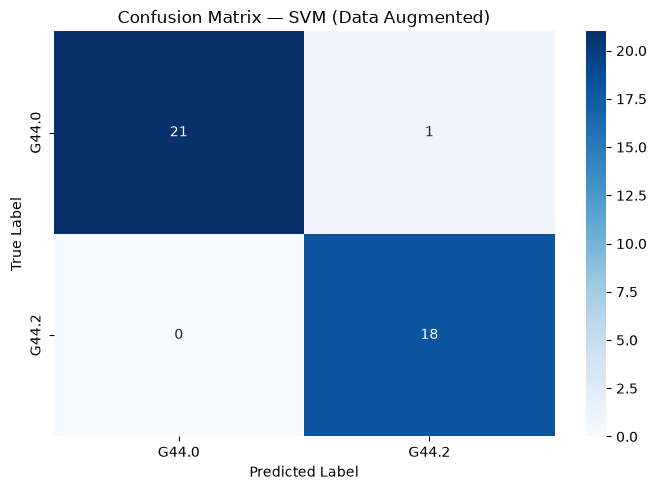

In [14]:
# --- Evaluasi Model SVM (Data Augmented) ---
y_pred_enc = svm_augmented.predict(X_test_tfidf)

accuracy           = accuracy_score(y_test_enc, y_pred_enc)
f1_weighted        = f1_score(y_test_enc, y_pred_enc, average='weighted', zero_division=0)
precision_weighted = precision_score(y_test_enc, y_pred_enc, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test_enc, y_pred_enc, average='weighted', zero_division=0)

print("=== Evaluasi Model SVM — Data Augmented ===")
print(f"  Accuracy           : {accuracy:.4f}")
print(f"  Weighted F1-Score  : {f1_weighted:.4f}")
print(f"  Weighted Precision : {precision_weighted:.4f}")
print(f"  Weighted Recall    : {recall_weighted:.4f}")

print("\n--- Classification Report ---")
print(classification_report(
    y_test_enc, y_pred_enc,
    target_names=label_encoder.classes_,
    zero_division=0
))

# Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test_enc, y_pred_enc)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix — SVM (Data Augmented)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [15]:
# --- Top 10 Fitur Paling Penting (Berdasarkan Koefisien SVM Linear) ---
print("=== Top 10 Fitur TF-IDF Paling Penting (SVM Augmented) ===")
feature_names = tfidf_vectorizer.get_feature_names_out()

if hasattr(svm_augmented, 'coef_'):
    dense_coef = svm_augmented.coef_.toarray()

    # Untuk binary: gunakan langsung; untuk multi-class: rata-rata absolute
    if len(label_encoder.classes_) > 2:
        abs_coefficients = np.mean(np.abs(dense_coef), axis=0)
    else:
        abs_coefficients = np.abs(dense_coef).flatten()

    top_indices = abs_coefficients.argsort()[-10:][::-1]

    for i, idx in enumerate(top_indices):
        print(f"  {i+1:2d}. {feature_names[idx]:<25} (Magnitude: {abs_coefficients[idx]:.4f})")
else:
    print("Koefisien tidak tersedia untuk kernel SVM ini.")

=== Top 10 Fitur TF-IDF Paling Penting (SVM Augmented) ===
   1. terasa                    (Magnitude: 1.7608)
   2. kurang                    (Magnitude: 1.3400)
   3. lebih                     (Magnitude: 1.3400)
   4. belakang                  (Magnitude: 1.2635)
   5. pusing                    (Magnitude: 1.1776)
   6. kemarin                   (Magnitude: 1.0005)
   7. yang                      (Magnitude: 0.9988)
   8. alergi                    (Magnitude: 0.9974)
   9. sulit                     (Magnitude: 0.9902)
  10. depan                     (Magnitude: 0.9395)


## Langkah 9: Pemodelan SVM — Data Asli (Pembanding)

Melatih model SVM yang sama namun **hanya menggunakan data asli** (40 baris) tanpa augmentasi, sebagai baseline untuk perbandingan performa.

In [16]:
print("=== Pemodelan SVM untuk icd_x — Data Asli (Baseline) ===")

# Load dataset asli (tanpa augmentasi)
print(f"Memuat dataset asli dari: {PATH_DATASET_UTAMA}")
df_original = pd.read_excel(PATH_DATASET_UTAMA, header=1)
df_original.columns = df_original.columns.str.strip()

# Siapkan fitur dan label
X_orig = df_original['normalized_semicolon'].fillna('')
y_orig = df_original['icd_x']

# Encode label
label_encoder_orig = LabelEncoder()
y_orig_enc         = label_encoder_orig.fit_transform(y_orig)

print(f"Jumlah sampel        : {len(X_orig)}")
print(f"Jumlah kelas icd_x   : {len(label_encoder_orig.classes_)}")
print(f"Kelas                : {list(label_encoder_orig.classes_)}")

# Split data
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig_enc, test_size=0.2, random_state=42
)
print(f"\nJumlah data training : {len(X_train_o)}")
print(f"Jumlah data testing  : {len(X_test_o)}")

# Vektorisasi TF-IDF
tfidf_orig      = TfidfVectorizer(max_features=5000)
X_train_o_tfidf = tfidf_orig.fit_transform(X_train_o)
X_test_o_tfidf  = tfidf_orig.transform(X_test_o)

# Latih model SVM
print("\nMelatih model SVM (kernel=linear)...")
svm_original = SVC(kernel='linear', random_state=42)
svm_original.fit(X_train_o_tfidf, y_train_o)
print("Pelatihan selesai.")

=== Pemodelan SVM untuk icd_x — Data Asli (Baseline) ===
Memuat dataset asli dari: c:\Users\admin\Documents\Penelitian\CBR Research\Program\..\Dataset\dataset.xlsx
Jumlah sampel        : 40
Jumlah kelas icd_x   : 2
Kelas                : ['G44.0', 'G44.2']

Jumlah data training : 32
Jumlah data testing  : 8

Melatih model SVM (kernel=linear)...
Pelatihan selesai.


=== Evaluasi Model SVM — Data Asli ===
  Accuracy           : 0.5000
  Weighted F1-Score  : 0.4333
  Weighted Precision : 0.7857
  Weighted Recall    : 0.5000

--- Classification Report ---
              precision    recall  f1-score   support

       G44.0       1.00      0.20      0.33         5
       G44.2       0.43      1.00      0.60         3

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8

--- Confusion Matrix ---


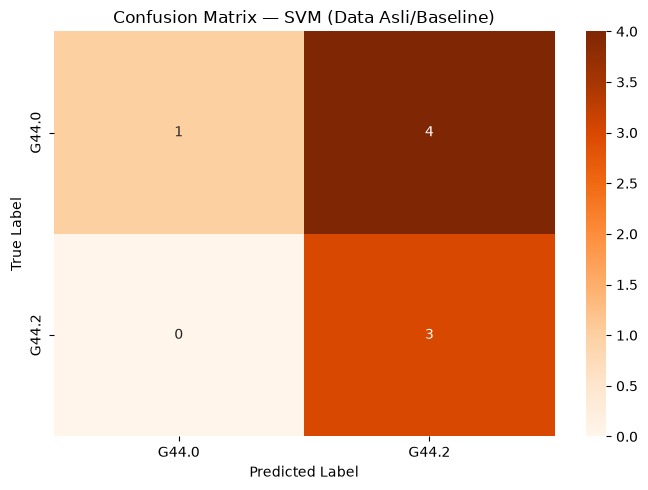

In [17]:
# --- Evaluasi Model SVM (Data Asli) ---
y_pred_o = svm_original.predict(X_test_o_tfidf)

accuracy_o  = accuracy_score(y_test_o, y_pred_o)
f1_o        = f1_score(y_test_o, y_pred_o, average='weighted', zero_division=0)
precision_o = precision_score(y_test_o, y_pred_o, average='weighted', zero_division=0)
recall_o    = recall_score(y_test_o, y_pred_o, average='weighted', zero_division=0)

print("=== Evaluasi Model SVM — Data Asli ===")
print(f"  Accuracy           : {accuracy_o:.4f}")
print(f"  Weighted F1-Score  : {f1_o:.4f}")
print(f"  Weighted Precision : {precision_o:.4f}")
print(f"  Weighted Recall    : {recall_o:.4f}")

print("\n--- Classification Report ---")
print(classification_report(
    y_test_o, y_pred_o,
    target_names=label_encoder_orig.classes_,
    zero_division=0
))

# Confusion Matrix
print("--- Confusion Matrix ---")
cm_o = confusion_matrix(y_test_o, y_pred_o)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_o, annot=True, fmt="d", cmap="Oranges",
    xticklabels=label_encoder_orig.classes_,
    yticklabels=label_encoder_orig.classes_
)
plt.title('Confusion Matrix — SVM (Data Asli/Baseline)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Langkah 10: Perbandingan Performa SVM — Sebelum vs Sesudah Augmentasi

Membandingkan hasil evaluasi model SVM pada data asli (baseline) versus data yang telah diaugmentasi.

=== Perbandingan Performa Model SVM ===
                      Data Asli  Data Augmented  Selisih
Metrik                                                  
Accuracy                 0.5000          0.9750   0.4750
F1-Score (Weighted)      0.4333          0.9750   0.5417
Precision (Weighted)     0.7857          0.9763   0.1906
Recall (Weighted)        0.5000          0.9750   0.4750


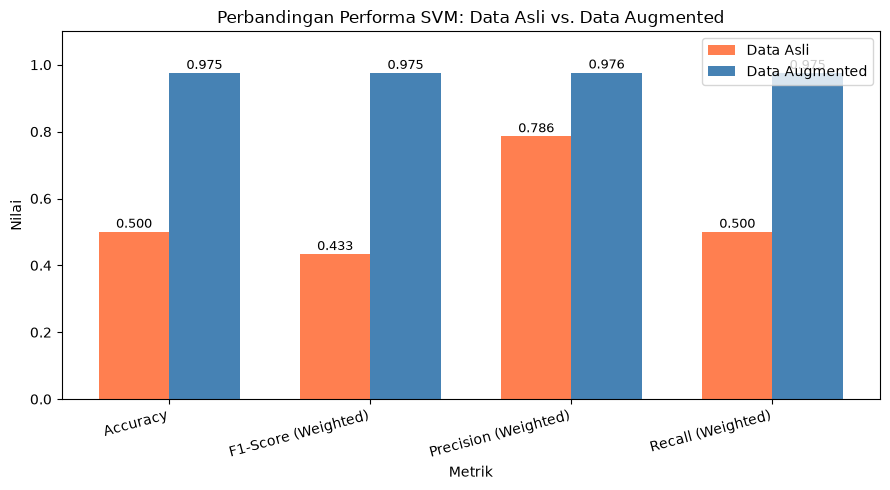

In [18]:
# --- Tabel Perbandingan ---
hasil_perbandingan = pd.DataFrame({
    'Metrik'        : ['Accuracy', 'F1-Score (Weighted)', 'Precision (Weighted)', 'Recall (Weighted)'],
    'Data Asli'     : [accuracy_o,  f1_o,         precision_o,       recall_o],
    'Data Augmented': [accuracy,    f1_weighted,  precision_weighted, recall_weighted]
})
hasil_perbandingan['Selisih'] = hasil_perbandingan['Data Augmented'] - hasil_perbandingan['Data Asli']
hasil_perbandingan = hasil_perbandingan.set_index('Metrik')

print("=== Perbandingan Performa Model SVM ===")
print(hasil_perbandingan.to_string(float_format='{:.4f}'.format))

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(hasil_perbandingan))
width = 0.35

bars1 = ax.bar([xi - width/2 for xi in x], hasil_perbandingan['Data Asli'],      width, label='Data Asli',      color='coral')
bars2 = ax.bar([xi + width/2 for xi in x], hasil_perbandingan['Data Augmented'], width, label='Data Augmented', color='steelblue')

ax.set_xlabel('Metrik')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Performa SVM: Data Asli vs. Data Augmented')
ax.set_xticks(list(x))
ax.set_xticklabels(hasil_perbandingan.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()

# Tambahkan nilai di atas setiap bar
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

# Metode CBR (Case-Based Reasoning) dengan Cosine Similarity

Bagian ini mengimplementasikan sistem CBR menggunakan **data hasil augmentasi** sebagai basis kasus, mengikuti siklus **4R**:

```
Query Baru
    │
    ▼
┌──────────────────────────────────────────────────────────┐
│  1. RETRIEVE  — Ambil kasus paling mirip dari basis kasus │
│                 (data augmented, 200 kasus)               │
│                 menggunakan Cosine Similarity             │
│                 (threshold ≥ 0.70)                        │
│                                                          │
│  2. REUSE     — Weighted majority voting dari kasus       │
│                 yang ditemukan                            │
│                                                          │
│  3. REVISE    — Validasi/koreksi solusi jika diperlukan  │
│                                                          │
│  4. RETAIN    — Simpan kasus baru ke basis kasus         │
└──────────────────────────────────────────────────────────┘
    │
    ▼
Solusi Diagnosis
```

| Parameter | Nilai |
|-----------|-------|
| **Basis kasus** | `dataset_augmented.xlsx` (200 kasus) |
| Representasi kasus | TF-IDF (unigram + bigram) dari `normalized_semicolon` |
| Fungsi kemiripan | **Cosine Similarity** |
| Threshold | **≥ 0.70** |
| Strategi voting | Weighted majority vote (bobot = similarity) |
| Evaluasi | Leave-One-Out Cross-Validation (LOO-CV) |

## Langkah 11: Representasi Basis Kasus dari Data Augmented

Memuat **dataset hasil augmentasi** (200 baris) sebagai basis kasus CBR, kemudian membangun matriks TF-IDF yang menjadi representasi seluruh kasus.

In [19]:
# ─────────────────────────────────────────────────────────────
# 11.1  Muat dataset AUGMENTED sebagai basis kasus CBR
# ─────────────────────────────────────────────────────────────
print(f"Memuat dataset augmented untuk basis kasus CBR: {PATH_DATASET_AUGMENTED}")
df_cbr = pd.read_excel(PATH_DATASET_AUGMENTED)
df_cbr.columns = df_cbr.columns.str.strip()

# Pastikan tidak ada missing value di kolom kunci
df_cbr = df_cbr.dropna(subset=['normalized_semicolon', 'icd_x']).reset_index(drop=True)

print(f"\nJumlah kasus dalam basis kasus (augmented) : {len(df_cbr)}")
print(f"Distribusi label icd_x:")
print(df_cbr['icd_x'].value_counts().to_string())

# Tampilkan komposisi sumber data (asli vs augmentasi)
if 'sumber_data' in df_cbr.columns:
    print(f"\nKomposisi sumber data:")
    print(df_cbr['sumber_data'].value_counts().to_string())

Memuat dataset augmented untuk basis kasus CBR: c:\Users\admin\Documents\Penelitian\CBR Research\Program\..\Dataset\dataset_augmented.xlsx

Jumlah kasus dalam basis kasus (augmented) : 200
Distribusi label icd_x:
icd_x
G44.0    100
G44.2    100

Komposisi sumber data:
sumber_data
Data Asli                      40
RandomDeletion Augment ke-1    40
RandomDeletion Augment ke-2    40
RandomDeletion Augment ke-3    40
RandomDeletion Augment ke-4    40


In [20]:
# ─────────────────────────────────────────────────────────────
# 11.2  Bangun TF-IDF vectorizer dari seluruh basis kasus augmented
#        Menggunakan unigram + bigram untuk representasi lebih kaya
# ─────────────────────────────────────────────────────────────
THRESHOLD_SIMILARITY = 0.70   # Threshold cosine similarity CBR

cbr_vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
case_base_matrix = cbr_vectorizer.fit_transform(df_cbr['normalized_semicolon'])

print(f"Dimensi matriks TF-IDF basis kasus augmented : {case_base_matrix.shape}")
print(f"  Baris  = jumlah kasus                      : {case_base_matrix.shape[0]}")
print(f"  Kolom  = jumlah fitur (n-gram)             : {case_base_matrix.shape[1]}")
print(f"\nThreshold Cosine Similarity                  : {THRESHOLD_SIMILARITY}")

Dimensi matriks TF-IDF basis kasus augmented : (200, 741)
  Baris  = jumlah kasus                      : 200
  Kolom  = jumlah fitur (n-gram)             : 741

Threshold Cosine Similarity                  : 0.7


## Langkah 12: Fungsi Inti CBR

Mendefinisikan fungsi-fungsi utama siklus CBR:
- **`cbr_retrieve()`** — Fase Retrieve: cari kasus terdekat ≥ threshold dari basis kasus augmented
- **`cbr_reuse()`** — Fase Reuse: tentukan solusi via weighted majority voting
- **`cbr_predict()`** — Gabungan Retrieve + Reuse untuk satu query

In [21]:
def cbr_retrieve(query_text, case_base_tfidf, df_cases,
                 vectorizer, threshold=0.70, top_k=5):
    """
    FASE RETRIEVE: Ambil kasus-kasus paling mirip dari basis kasus augmented.

    Algoritma:
      1. Transformasikan teks query ke vektor TF-IDF
      2. Hitung cosine similarity antara query dengan semua kasus
      3. Filter kasus dengan similarity >= threshold (0.70)
      4. Urutkan dari yang paling mirip, ambil top_k teratas

    Args:
        query_text      (str)            : Teks gejala query baru (dipisah ';')
        case_base_tfidf (sparse matrix)  : Matriks TF-IDF basis kasus
        df_cases        (DataFrame)      : DataFrame basis kasus
        vectorizer      (TfidfVectorizer): Vectorizer yang sudah di-fit
        threshold       (float)          : Minimal cosine similarity (default 0.70)
        top_k           (int)            : Maksimum kasus yang dikembalikan

    Returns:
        DataFrame: Kasus yang memenuhi threshold + kolom 'similarity'.
                   Kosong jika tidak ada kasus yang memenuhi threshold.
    """
    query_vec    = vectorizer.transform([query_text])
    similarities = cosine_similarity(query_vec, case_base_tfidf).flatten()

    df_result = df_cases.copy()
    df_result['similarity'] = similarities
    df_result = df_result[df_result['similarity'] >= threshold]
    df_result = df_result.sort_values('similarity', ascending=False).head(top_k)
    return df_result.reset_index(drop=True)


def cbr_reuse(retrieved_cases):
    """
    FASE REUSE: Tentukan solusi dari kasus-kasus yang ditemukan.

    Strategi: Weighted Majority Voting
      - Tiap kasus memberikan suara untuk label icd_x-nya
      - Bobot suara = nilai cosine similarity
      - Label dengan total bobot tertinggi dipilih sebagai prediksi
      - Confidence = bobot label terpilih / total bobot semua kasus

    Args:
        retrieved_cases (DataFrame): Output dari cbr_retrieve()

    Returns:
        tuple: (predicted_label, confidence_score)
               predicted_label = None jika tidak ada kasus mirip.
    """
    if retrieved_cases.empty:
        return None, 0.0

    vote_scores     = retrieved_cases.groupby('icd_x')['similarity'].sum()
    predicted_label = vote_scores.idxmax()
    total_sim       = retrieved_cases['similarity'].sum()
    confidence      = vote_scores[predicted_label] / total_sim if total_sim > 0 else 0.0

    return predicted_label, round(float(confidence), 4)


def cbr_predict(query_text, case_base_tfidf, df_cases,
                vectorizer, threshold=0.70, top_k=5):
    """
    Gabungan Retrieve + Reuse untuk satu query.

    Returns:
        dict: {
            'prediksi'    : label icd_x atau None,
            'confidence'  : bobot keyakinan (0.0–1.0),
            'kasus_mirip' : DataFrame kasus yang ditemukan,
            'ada_kasus'   : bool
        }
    """
    kasus_mirip    = cbr_retrieve(query_text, case_base_tfidf, df_cases,
                                  vectorizer, threshold, top_k)
    prediksi, conf = cbr_reuse(kasus_mirip)
    return {
        'prediksi'   : prediksi,
        'confidence' : conf,
        'kasus_mirip': kasus_mirip,
        'ada_kasus'  : not kasus_mirip.empty
    }


print("Fungsi CBR (retrieve, reuse, predict) berhasil didefinisikan.")
print(f"Threshold cosine similarity: {THRESHOLD_SIMILARITY}")
print(f"Basis kasus                : {len(df_cbr)} kasus (data augmented)")

Fungsi CBR (retrieve, reuse, predict) berhasil didefinisikan.
Threshold cosine similarity: 0.7
Basis kasus                : 200 kasus (data augmented)


## Langkah 13: Demo — Query Kasus Baru

Menjalankan CBR pada satu contoh query gejala baru. Sistem akan mencari kasus mirip dari **basis kasus augmented** (200 kasus), kemudian memberikan prediksi diagnosis.

In [22]:
# ─────────────────────────────────────────────────────────────
# Contoh query: masukkan gejala baru dipisah titik koma
# ─────────────────────────────────────────────────────────────
QUERY_BARU = "demam 3 hari;pusing;bab lembek;perut mual nihil;muntah nihil;alergi obat nihil"

print("=" * 60)
print("         SISTEM CBR — DEMO QUERY KASUS BARU")
print("=" * 60)
print(f"\n[INPUT]  Gejala Query  : {QUERY_BARU}")
print(f"[CONFIG] Threshold     : {THRESHOLD_SIMILARITY}")
print(f"[CONFIG] Basis Kasus   : {len(df_cbr)} kasus (data augmented)")
print(f"[CONFIG] Max Top-K     : 5")

hasil = cbr_predict(
    query_text      = QUERY_BARU,
    case_base_tfidf = case_base_matrix,
    df_cases        = df_cbr,
    vectorizer      = cbr_vectorizer,
    threshold       = THRESHOLD_SIMILARITY,
    top_k           = 5
)

# --- Fase RETRIEVE ---
print("\n─── FASE RETRIEVE ──────────────────────────────────────")
if hasil['ada_kasus']:
    cols_show = ['icd_x', 'normalized_semicolon', 'similarity']
    if 'sumber_data' in df_cbr.columns:
        cols_show = ['icd_x', 'sumber_data', 'normalized_semicolon', 'similarity']
    kasus_tampil = hasil['kasus_mirip'][cols_show].copy()
    kasus_tampil['normalized_semicolon'] = kasus_tampil['normalized_semicolon'].str[:60] + '...'
    kasus_tampil['similarity'] = kasus_tampil['similarity'].round(4)
    print(f"Ditemukan {len(hasil['kasus_mirip'])} kasus mirip (similarity >= {THRESHOLD_SIMILARITY}):")
    display(kasus_tampil)
else:
    print(f"Tidak ada kasus dengan similarity >= {THRESHOLD_SIMILARITY}.")
    print("Sistem tidak dapat memberikan rekomendasi — perlu konsultasi dokter.")

# --- Fase REUSE ---
print("\n─── FASE REUSE ─────────────────────────────────────────")
if hasil['prediksi']:
    print(f"[OUTPUT] Prediksi Diagnosis  : {hasil['prediksi']}")
    print(f"[OUTPUT] Confidence          : {hasil['confidence']:.2%}")
    print("\nKeterangan kode ICD-X:")
    print("  G44.0 = Cluster headache (Sakit kepala klaster)")
    print("  G44.2 = Tension-type headache (Sakit kepala tegang)")
else:
    print("[OUTPUT] Prediksi : Tidak dapat ditentukan (di bawah threshold)")

print("=" * 60)

         SISTEM CBR — DEMO QUERY KASUS BARU

[INPUT]  Gejala Query  : demam 3 hari;pusing;bab lembek;perut mual nihil;muntah nihil;alergi obat nihil
[CONFIG] Threshold     : 0.7
[CONFIG] Basis Kasus   : 200 kasus (data augmented)
[CONFIG] Max Top-K     : 5

─── FASE RETRIEVE ──────────────────────────────────────
Ditemukan 4 kasus mirip (similarity >= 0.7):


,icd_x,sumber_data,normalized_semicolon,similarity
0,G44.0,Data Asli,demam 3 hari;pusing;bab lembek;perut mual nihi...,1.0000
1,G44.0,RandomDeletion Augment ke-2,demam 3 hari;pusing;bab lembek;perut mual nihi...,1.0000
2,G44.0,RandomDeletion Augment ke-3,pusing;bab lembek;perut mual nihil;muntah nihi...,0.9101
3,G44.0,RandomDeletion Augment ke-4,demam 3 hari;pusing;perut mual nihil;muntah ni...,0.7134



─── FASE REUSE ─────────────────────────────────────────
[OUTPUT] Prediksi Diagnosis  : G44.0
[OUTPUT] Confidence          : 100.00%

Keterangan kode ICD-X:
  G44.0 = Cluster headache (Sakit kepala klaster)
  G44.2 = Tension-type headache (Sakit kepala tegang)


## Langkah 14: Evaluasi CBR — Leave-One-Out Cross-Validation (LOO-CV)

Mengevaluasi performa CBR menggunakan **Leave-One-Out Cross-Validation** pada **data augmented** (200 kasus):

1. Setiap kasus (dari 200 kasus augmented) diuji satu per satu sebagai query
2. Kasus yang sedang diuji **dikeluarkan sementara** dari basis kasus (mencegah data leakage)
3. Sisa 199 kasus menjadi basis kasus untuk proses Retrieve
4. Hasilnya dicatat: **BENAR** / **SALAH** / **TIDAK_TERJAWAB**

> ⚠️ **Catatan**: Basis kasus yang lebih besar (200 vs 40) meningkatkan kemungkinan menemukan kasus mirip karena data augmented mencakup variasi gejala yang lebih beragam.

In [23]:
print("=== Evaluasi CBR — Leave-One-Out Cross-Validation ===")
print(f"Dataset         : {len(df_cbr)} kasus (data augmented)")
print(f"Threshold       : {THRESHOLD_SIMILARITY}")
print("Memulai LOO-CV (200 iterasi)...\n")

y_true_cbr   = []
y_pred_cbr   = []
detail_hasil = []

for i in range(len(df_cbr)):
    # Pisahkan kasus ke-i sebagai query, sisanya sebagai basis kasus
    df_train   = df_cbr.drop(index=i).reset_index(drop=True)
    query_text = df_cbr.loc[i, 'normalized_semicolon']
    true_label = df_cbr.loc[i, 'icd_x']

    # Bangun matriks TF-IDF dari basis kasus sementara (tanpa kasus ke-i)
    train_matrix = cbr_vectorizer.transform(df_train['normalized_semicolon'])

    # Jalankan CBR
    hasil_i = cbr_predict(
        query_text      = query_text,
        case_base_tfidf = train_matrix,
        df_cases        = df_train,
        vectorizer      = cbr_vectorizer,
        threshold       = THRESHOLD_SIMILARITY,
        top_k           = 5
    )

    pred_label  = hasil_i['prediksi']
    confidence  = hasil_i['confidence']
    n_retrieved = len(hasil_i['kasus_mirip'])

    y_true_cbr.append(true_label)
    y_pred_cbr.append(pred_label if pred_label is not None else 'TIDAK_TERJAWAB')

    detail_hasil.append({
        'no'           : i + 1,
        'sumber_data'  : df_cbr.loc[i, 'sumber_data'] if 'sumber_data' in df_cbr.columns else '-',
        'query_singkat': str(query_text)[:55] + '...',
        'label_asli'   : true_label,
        'prediksi_cbr' : pred_label,
        'confidence'   : confidence,
        'n_retrieved'  : n_retrieved,
        'status'       : 'BENAR' if pred_label == true_label else
                         ('TIDAK_TERJAWAB' if pred_label is None else 'SALAH')
    })

    # Progress log setiap 50 iterasi
    if (i + 1) % 50 == 0:
        print(f"  Progress: {i + 1}/{len(df_cbr)} kasus selesai...")

print(f"\nLOO-CV selesai. {len(df_cbr)} kasus dievaluasi.")

=== Evaluasi CBR — Leave-One-Out Cross-Validation ===
Dataset         : 200 kasus (data augmented)
Threshold       : 0.7
Memulai LOO-CV (200 iterasi)...

  Progress: 50/200 kasus selesai...
  Progress: 100/200 kasus selesai...
  Progress: 150/200 kasus selesai...
  Progress: 200/200 kasus selesai...

LOO-CV selesai. 200 kasus dievaluasi.


In [24]:
# ─────────────────────────────────────────────────────────────
# Tampilkan tabel detail hasil LOO-CV
# ─────────────────────────────────────────────────────────────
df_detail = pd.DataFrame(detail_hasil)

status_counts = df_detail['status'].value_counts()
print("=== Rekap Status Prediksi CBR (LOO-CV, Data Augmented) ===")
for status, cnt in status_counts.items():
    print(f"  {status:<20}: {cnt} kasus")

# Breakdown per sumber data (asli vs augmentasi)
if 'sumber_data' in df_detail.columns:
    print("\n--- Breakdown per Sumber Data ---")
    breakdown = df_detail.groupby(['sumber_data', 'status']).size().unstack(fill_value=0)
    display(breakdown)

print("\n--- Tabel Detail Hasil LOO-CV (10 baris pertama) ---")
display(df_detail[['no', 'sumber_data', 'label_asli', 'prediksi_cbr',
                   'confidence', 'n_retrieved', 'status']].head(10))

=== Rekap Status Prediksi CBR (LOO-CV, Data Augmented) ===
  BENAR               : 192 kasus
  TIDAK_TERJAWAB      : 8 kasus

--- Breakdown per Sumber Data ---


status,BENAR,TIDAK_TERJAWAB
sumber_data,,
Data Asli,40,0
RandomDeletion Augment ke-1,39,1
RandomDeletion Augment ke-2,38,2
RandomDeletion Augment ke-3,36,4
RandomDeletion Augment ke-4,39,1



--- Tabel Detail Hasil LOO-CV (10 baris pertama) ---


,no,sumber_data,label_asli,prediksi_cbr,confidence,n_retrieved,status
0,1,Data Asli,G44.0,G44.0,1.0,3,BENAR
1,2,Data Asli,G44.0,G44.0,1.0,3,BENAR
2,3,Data Asli,G44.0,G44.0,1.0,4,BENAR
3,4,Data Asli,G44.0,G44.0,1.0,4,BENAR
4,5,Data Asli,G44.0,G44.0,1.0,4,BENAR
5,6,Data Asli,G44.0,G44.0,1.0,2,BENAR
6,7,Data Asli,G44.0,G44.0,1.0,3,BENAR
7,8,Data Asli,G44.0,G44.0,1.0,3,BENAR
8,9,Data Asli,G44.0,G44.0,1.0,4,BENAR
9,10,Data Asli,G44.0,G44.0,1.0,4,BENAR


In [25]:
# ─────────────────────────────────────────────────────────────
# Hitung metrik evaluasi CBR
# ─────────────────────────────────────────────────────────────
df_terjawab       = df_detail[df_detail['prediksi_cbr'].notna()]
df_tidak_terjawab = df_detail[df_detail['prediksi_cbr'].isna()]

n_total          = len(df_cbr)
n_terjawab       = len(df_terjawab)
n_tidak_terjawab = len(df_tidak_terjawab)
n_benar          = (df_detail['status'] == 'BENAR').sum()
n_salah          = (df_detail['status'] == 'SALAH').sum()

coverage         = n_terjawab / n_total
accuracy_overall = n_benar / n_total
accuracy_cond    = n_benar / n_terjawab if n_terjawab > 0 else 0.0

y_true_t = df_terjawab['label_asli'].tolist()
y_pred_t = df_terjawab['prediksi_cbr'].tolist()

f1_cbr        = f1_score(y_true_t, y_pred_t, average='weighted', zero_division=0)        if n_terjawab > 0 else 0.0
precision_cbr = precision_score(y_true_t, y_pred_t, average='weighted', zero_division=0) if n_terjawab > 0 else 0.0
recall_cbr    = recall_score(y_true_t, y_pred_t, average='weighted', zero_division=0)    if n_terjawab > 0 else 0.0

avg_confidence  = df_terjawab['confidence'].mean()  if n_terjawab > 0 else 0.0
avg_n_retrieved = df_terjawab['n_retrieved'].mean() if n_terjawab > 0 else 0.0

print("=" * 60)
print("   HASIL EVALUASI CBR — DATA AUGMENTED (LOO-CV)")
print("=" * 60)
print(f"  Basis Kasus                   : {n_total} kasus (augmented)")
print(f"  Threshold Cosine Similarity   : {THRESHOLD_SIMILARITY}")
print(f"  Kasus Terjawab                : {n_terjawab} ({coverage:.1%})")
print(f"  Kasus Tidak Terjawab          : {n_tidak_terjawab} ({1-coverage:.1%})")
print(f"  Prediksi BENAR                : {n_benar}")
print(f"  Prediksi SALAH                : {n_salah}")
print()
print(f"  ── Metrik (semua kasus) ──────────────────────")
print(f"  Accuracy (Overall)            : {accuracy_overall:.4f}")
print(f"  Coverage                      : {coverage:.4f}")
print()
print(f"  ── Metrik (kasus terjawab saja) ──────────────")
print(f"  Accuracy (Conditional)        : {accuracy_cond:.4f}")
print(f"  Weighted F1-Score             : {f1_cbr:.4f}")
print(f"  Weighted Precision            : {precision_cbr:.4f}")
print(f"  Weighted Recall               : {recall_cbr:.4f}")
print(f"  Rata-rata Confidence          : {avg_confidence:.4f}")
print(f"  Rata-rata Kasus Ditemukan     : {avg_n_retrieved:.2f}")
print("=" * 60)

   HASIL EVALUASI CBR — DATA AUGMENTED (LOO-CV)
  Basis Kasus                   : 200 kasus (augmented)
  Threshold Cosine Similarity   : 0.7
  Kasus Terjawab                : 192 (96.0%)
  Kasus Tidak Terjawab          : 8 (4.0%)
  Prediksi BENAR                : 192
  Prediksi SALAH                : 0

  ── Metrik (semua kasus) ──────────────────────
  Accuracy (Overall)            : 0.9600
  Coverage                      : 0.9600

  ── Metrik (kasus terjawab saja) ──────────────
  Accuracy (Conditional)        : 1.0000
  Weighted F1-Score             : 1.0000
  Weighted Precision            : 1.0000
  Weighted Recall               : 1.0000
  Rata-rata Confidence          : 1.0000
  Rata-rata Kasus Ditemukan     : 3.54


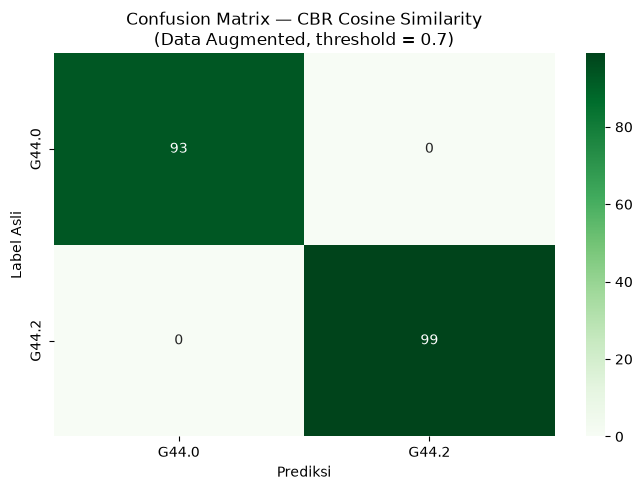


--- Classification Report CBR (Kasus Terjawab) ---
              precision    recall  f1-score   support

       G44.0       1.00      1.00      1.00        93
       G44.2       1.00      1.00      1.00        99

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192



In [26]:
# ─────────────────────────────────────────────────────────────
# Confusion Matrix CBR (kasus terjawab)
# ─────────────────────────────────────────────────────────────
if n_terjawab > 0:
    classes_cbr = sorted(df_cbr['icd_x'].unique())
    cm_cbr = confusion_matrix(y_true_t, y_pred_t, labels=classes_cbr)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm_cbr, annot=True, fmt='d', cmap='Greens',
        xticklabels=classes_cbr,
        yticklabels=classes_cbr
    )
    plt.title(f'Confusion Matrix — CBR Cosine Similarity\n(Data Augmented, threshold = {THRESHOLD_SIMILARITY})')
    plt.xlabel('Prediksi')
    plt.ylabel('Label Asli')
    plt.tight_layout()
    plt.show()

    print("\n--- Classification Report CBR (Kasus Terjawab) ---")
    print(classification_report(y_true_t, y_pred_t,
                                labels=classes_cbr, zero_division=0))

Menghitung distribusi max cosine similarity (200 iterasi)...


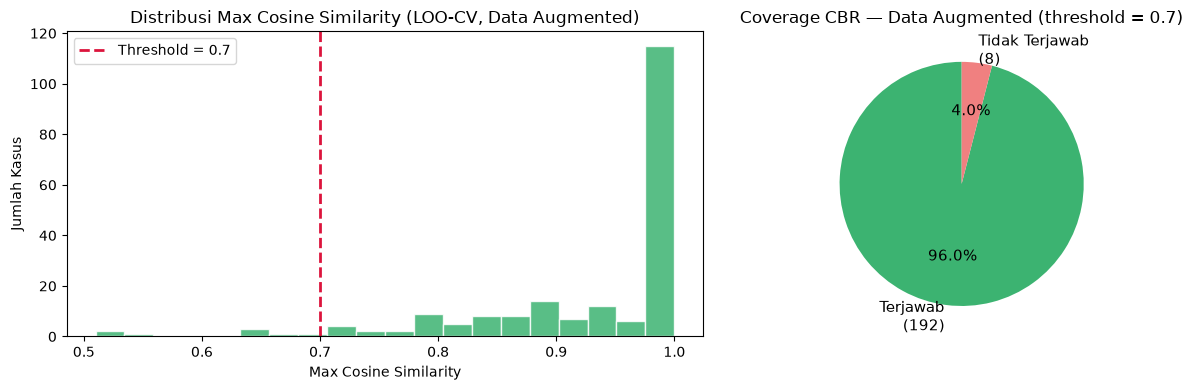

In [27]:
# ─────────────────────────────────────────────────────────────
# Visualisasi: Distribusi max-similarity + Coverage pie chart
# ─────────────────────────────────────────────────────────────
print("Menghitung distribusi max cosine similarity (200 iterasi)...")
max_sims = []
for i in range(len(df_cbr)):
    df_train_i  = df_cbr.drop(index=i).reset_index(drop=True)
    train_mat_i = cbr_vectorizer.transform(df_train_i['normalized_semicolon'])
    query_vec_i = cbr_vectorizer.transform([df_cbr.loc[i, 'normalized_semicolon']])
    sims_i      = cosine_similarity(query_vec_i, train_mat_i).flatten()
    max_sims.append(float(sims_i.max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Histogram distribusi max-similarity
axes[0].hist(max_sims, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(THRESHOLD_SIMILARITY, color='crimson', linestyle='--',
                linewidth=2, label=f'Threshold = {THRESHOLD_SIMILARITY}')
axes[0].set_title('Distribusi Max Cosine Similarity (LOO-CV, Data Augmented)')
axes[0].set_xlabel('Max Cosine Similarity')
axes[0].set_ylabel('Jumlah Kasus')
axes[0].legend()

# Plot 2: Pie chart coverage
labels_pie = [f'Terjawab\n({n_terjawab})', f'Tidak Terjawab\n({n_tidak_terjawab})']
sizes_pie  = [n_terjawab, n_tidak_terjawab]
colors_pie = ['mediumseagreen', 'lightcoral']
axes[1].pie(sizes_pie, labels=labels_pie, colors=colors_pie,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'Coverage CBR — Data Augmented (threshold = {THRESHOLD_SIMILARITY})')

plt.tight_layout()
plt.show()

## Langkah 15: Perbandingan CBR vs SVM

Membandingkan performa **CBR Cosine Similarity (data augmented)** dengan model **SVM** (data asli dan augmented).

In [28]:
# ─────────────────────────────────────────────────────────────
# Tabel perbandingan CBR vs SVM
# ─────────────────────────────────────────────────────────────
col_cbr_overall = f'CBR Augmented\n(thr={THRESHOLD_SIMILARITY}, Overall)'
col_cbr_cond    = f'CBR Augmented\n(thr={THRESHOLD_SIMILARITY}, Conditional)'

df_compare = pd.DataFrame({
    'Metrik'               : ['Accuracy', 'F1-Score (Weighted)',
                               'Precision (Weighted)', 'Recall (Weighted)'],
    'SVM — Data Asli'      : [accuracy_o,       f1_o,        precision_o,       recall_o],
    'SVM — Data Augmented' : [accuracy,         f1_weighted, precision_weighted, recall_weighted],
    col_cbr_overall        : [accuracy_overall, f1_cbr,      precision_cbr,      recall_cbr],
    col_cbr_cond           : [accuracy_cond,    f1_cbr,      precision_cbr,      recall_cbr],
})
df_compare = df_compare.set_index('Metrik')

print("=== Perbandingan Performa: CBR (Augmented) vs SVM ===")
print(df_compare.to_string(float_format='{:.4f}'.format))
print(f"\n* CBR Coverage (kasus yang berhasil dijawab): {coverage:.4f} ({coverage:.1%})")
print(f"* Basis kasus CBR: {n_total} kasus (data augmented)")

=== Perbandingan Performa: CBR (Augmented) vs SVM ===
                      SVM — Data Asli  SVM — Data Augmented  CBR Augmented\n(thr=0.7, Overall)  CBR Augmented\n(thr=0.7, Conditional)
Metrik                                                                                                                               
Accuracy                       0.5000                0.9750                             0.9600                                 1.0000
F1-Score (Weighted)            0.4333                0.9750                             1.0000                                 1.0000
Precision (Weighted)           0.7857                0.9763                             1.0000                                 1.0000
Recall (Weighted)              0.5000                0.9750                             1.0000                                 1.0000

* CBR Coverage (kasus yang berhasil dijawab): 0.9600 (96.0%)
* Basis kasus CBR: 200 kasus (data augmented)


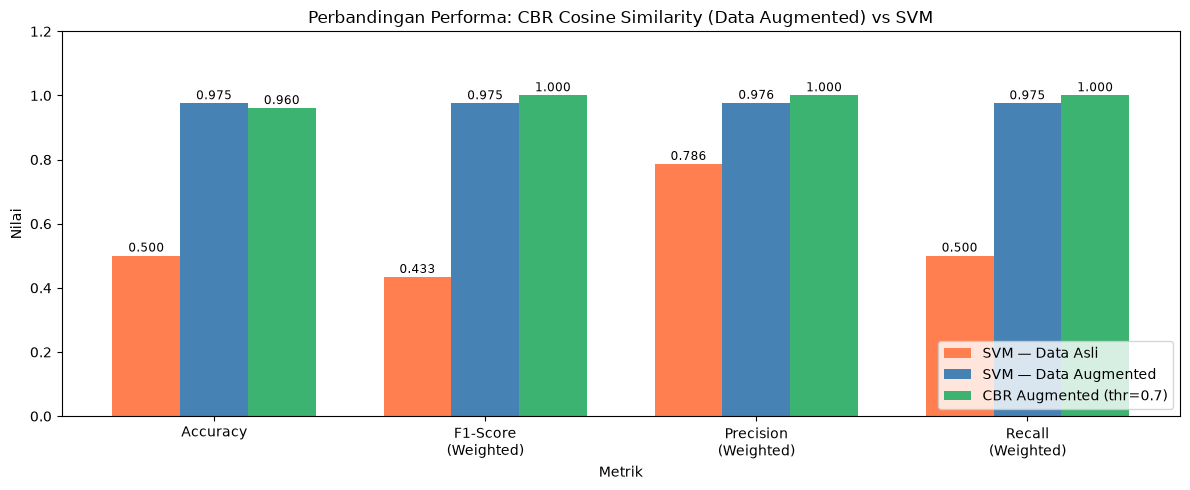

In [29]:
# ─────────────────────────────────────────────────────────────
# Visualisasi perbandingan CBR vs SVM
# ─────────────────────────────────────────────────────────────
metrik_labels = ['Accuracy', 'F1-Score\n(Weighted)',
                 'Precision\n(Weighted)', 'Recall\n(Weighted)']

vals_svm_asli = [accuracy_o,       f1_o,        precision_o,       recall_o]
vals_svm_aug  = [accuracy,          f1_weighted, precision_weighted, recall_weighted]
vals_cbr_aug  = [accuracy_overall,  f1_cbr,      precision_cbr,      recall_cbr]

x     = np.arange(len(metrik_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x - width, vals_svm_asli, width, label='SVM — Data Asli',                         color='coral')
b2 = ax.bar(x,          vals_svm_aug,  width, label='SVM — Data Augmented',                    color='steelblue')
b3 = ax.bar(x + width,  vals_cbr_aug,  width, label=f'CBR Augmented (thr={THRESHOLD_SIMILARITY})', color='mediumseagreen')

ax.set_xlabel('Metrik')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Performa: CBR Cosine Similarity (Data Augmented) vs SVM')
ax.set_xticks(x)
ax.set_xticklabels(metrik_labels)
ax.set_ylim(0, 1.20)
ax.legend(loc='lower right')

# Anotasi nilai di atas bar
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

## Langkah 16: Fase RETAIN — Menyimpan Kasus Baru ke Basis Kasus

Fase **RETAIN** adalah fase terakhir siklus CBR. Setelah solusi divalidasi oleh dokter, kasus baru ditambahkan ke **basis kasus augmented** agar sistem terus berkembang.

In [30]:
def cbr_retain(df_case_base, new_case_text, true_label, vectorizer,
               sumber='Kasus Baru'):
    """
    FASE RETAIN: Tambahkan kasus baru ke basis kasus dan
    perbarui representasi TF-IDF.

    Args:
        df_case_base  (DataFrame)      : Basis kasus saat ini
        new_case_text (str)            : Teks gejala kasus baru (dipisah ';')
        true_label    (str)            : Label diagnosis yang benar/tervalidasi
        vectorizer    (TfidfVectorizer): Vectorizer yang sudah di-fit
        sumber        (str)            : Keterangan sumber data

    Returns:
        tuple: (df_updated DataFrame, matrix_updated sparse matrix)
    """
    new_row = pd.DataFrame([{
        'normalized_semicolon': new_case_text,
        'icd_x'              : true_label,
        'sumber_data'        : sumber
    }])
    df_updated     = pd.concat([df_case_base, new_row], ignore_index=True)
    matrix_updated = vectorizer.transform(df_updated['normalized_semicolon'])
    return df_updated, matrix_updated


# ─── Contoh penggunaan RETAIN ───────────────────────────────
KASUS_BARU_TEXT = "kepala pusing berdenyut sebelah kanan;mual;tidak nafsu makan"
LABEL_VALIDASI  = "G44.0"   # Dikonfirmasi oleh dokter

print("=== FASE RETAIN — Menyimpan Kasus Baru ke Basis Kasus ===")
print(f"  Kasus baru           : {KASUS_BARU_TEXT}")
print(f"  Label (tervalidasi)  : {LABEL_VALIDASI}")
print(f"  Basis kasus sebelum  : {len(df_cbr)} kasus (augmented)")

df_cbr_updated, case_base_matrix_updated = cbr_retain(
    df_case_base  = df_cbr,
    new_case_text = KASUS_BARU_TEXT,
    true_label    = LABEL_VALIDASI,
    vectorizer    = cbr_vectorizer,
    sumber        = 'Kasus Baru Tervalidasi'
)

print(f"  Basis kasus sesudah  : {len(df_cbr_updated)} kasus")
print("\n✓ Kasus baru berhasil ditambahkan ke basis kasus augmented!")

# --- Verifikasi ---
print("\n─── Verifikasi: Query Mirip dengan Kasus yang Baru Ditambahkan ─")
query_verif = "kepala berdenyut;mual;tidak mau makan"
verifikasi  = cbr_predict(
    query_text      = query_verif,
    case_base_tfidf = case_base_matrix_updated,
    df_cases        = df_cbr_updated,
    vectorizer      = cbr_vectorizer,
    threshold       = THRESHOLD_SIMILARITY
)
print(f"  Query          : {query_verif}")
print(f"  Prediksi       : {verifikasi['prediksi']}")
print(f"  Confidence     : {verifikasi['confidence']:.2%}")
print(f"  Kasus ditemukan: {len(verifikasi['kasus_mirip'])} kasus")

=== FASE RETAIN — Menyimpan Kasus Baru ke Basis Kasus ===
  Kasus baru           : kepala pusing berdenyut sebelah kanan;mual;tidak nafsu makan
  Label (tervalidasi)  : G44.0
  Basis kasus sebelum  : 200 kasus (augmented)
  Basis kasus sesudah  : 201 kasus

✓ Kasus baru berhasil ditambahkan ke basis kasus augmented!

─── Verifikasi: Query Mirip dengan Kasus yang Baru Ditambahkan ─
  Query          : kepala berdenyut;mual;tidak mau makan
  Prediksi       : None
  Confidence     : 0.00%
  Kasus ditemukan: 0 kasus


---

# Testing pada Kasus Baru — datatesting.xlsx`

Bagian ini menguji **model yang sudah dilatih** (SVM dan CBR) terhadap **kasus baru** yang belum pernah dilihat selama proses training maupun augmentasi.

| Aspek | SVM | CBR |
|-------|-----|-----|
| Model | SVM linear dilatih dari data augmented | Basis kasus augmented (200 kasus) |
| Input | TF-IDF `normalized_semicolon` | TF-IDF `normalized_semicolon` |
| Output | Label `icd_x` | Label `icd_x` + confidence + kasus mirip |
| Threshold | — | **Cosine Similarity ≥ 0.70** |


## Langkah 17: Load Dataset Testing

Membaca file `datatesting.xlsx` sebagai data uji eksternal. Format file sama dengan dataset utama (header di baris ke-2).

In [31]:
# ─────────────────────────────────────────────────────────────
# Load dataset testing eksternal
# ─────────────────────────────────────────────────────────────
PATH_DATASET_TESTING = os.path.join(DATASET_DIR, 'datatesting.xlsx')

print(f"Memuat dataset testing dari  : {os.path.abspath(PATH_DATASET_TESTING)}")
print(f"File ditemukan               : {os.path.exists(PATH_DATASET_TESTING)}")

df_test = pd.read_excel(PATH_DATASET_TESTING, header=0)
df_test.columns = df_test.columns.str.strip()
df_test = df_test.dropna(subset=['normalized_semicolon', 'icd_x']).reset_index(drop=True)

print(f"\nJumlah kasus testing         : {len(df_test)}")
print(f"Kolom                        : {list(df_test.columns)}")
print(f"\nDistribusi icd_x (testing):")
print(df_test['icd_x'].value_counts().to_string())

print("\n--- Pratinjau 5 Baris Pertama ---")
display(df_test[['icd_x', 'normalized_semicolon']].head())

Memuat dataset testing dari  : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset\datatesting.xlsx
File ditemukan               : True

Jumlah kasus testing         : 25
Kolom                        : ['no', 'case_id', 'no_raw', 'icd_x', 'raw_semicolon', 'normalized_semicolon', 'case_codes']

Distribusi icd_x (testing):
icd_x
G44.2    16
G44.0     9

--- Pratinjau 5 Baris Pertama ---


,icd_x,normalized_semicolon
0,G44.0,konsultasi rujukan;hidung masih mampet;pusing;...
1,G44.0,Pusing berputar;mual;muntah saat pusing;sejak ...
2,G44.0,nyeri kepala;badan meriang;mual;sejak 2 hari;a...
3,G44.0,pusing sebelah kiri;sejak kemarin;tengkuk bahu...
4,G44.0,Pusing;terasa tidak nyaman di badan;tengkuk te...


## Langkah 18: Testing dengan Model SVM

Menggunakan model SVM yang sudah dilatih dari **data augmented** (`svm_augmented` + `tfidf_vectorizer`) untuk memprediksi label tiap kasus testing.

> **Model tidak dilatih ulang** — ini adalah pengujian murni pada data yang belum pernah dilihat.

In [32]:
# ─────────────────────────────────────────────────────────────
# 18.1  Prediksi SVM pada data testing
# ─────────────────────────────────────────────────────────────
X_test_ext = df_test['normalized_semicolon'].fillna('')
y_true_ext = df_test['icd_x'].values

# Transform dengan tfidf_vectorizer yang sudah di-fit dari data augmented
X_test_ext_tfidf = tfidf_vectorizer.transform(X_test_ext)

# Prediksi
y_pred_svm_ext_enc = svm_augmented.predict(X_test_ext_tfidf)
y_pred_svm_ext     = label_encoder.inverse_transform(y_pred_svm_ext_enc)

# ─────────────────────────────────────────────────────────────
# 18.2  Tabel hasil prediksi SVM per kasus
# ─────────────────────────────────────────────────────────────
df_svm_result = df_test[['icd_x', 'normalized_semicolon']].copy()
df_svm_result.columns = ['label_asli', 'gejala']
df_svm_result['prediksi_svm'] = y_pred_svm_ext
df_svm_result['status'] = [
    'BENAR' if t == p else 'SALAH'
    for t, p in zip(y_true_ext, y_pred_svm_ext)
]
df_svm_result.index = range(1, len(df_svm_result) + 1)
df_svm_result.index.name = 'No'

print("=== Hasil Prediksi SVM per Kasus ===")
display(df_svm_result[['label_asli', 'prediksi_svm', 'status']])

=== Hasil Prediksi SVM per Kasus ===


,label_asli,prediksi_svm,status
No,,,
1,G44.0,G44.0,BENAR
2,G44.0,G44.0,BENAR
3,G44.0,G44.0,BENAR
4,G44.0,G44.0,BENAR
5,G44.0,G44.2,SALAH
6,G44.0,G44.0,BENAR
7,G44.0,G44.2,SALAH
8,G44.0,G44.0,BENAR
9,G44.0,G44.0,BENAR


   EVALUASI SVM — DATA TESTING EKSTERNAL
  Model          : SVM linear (dilatih dari data augmented)
  Jumlah kasus   : 25
  Benar          : 18
  Salah          : 7
  Accuracy       : 0.7200
  F1-Score (W)   : 0.7255
  Precision (W)  : 0.7515
  Recall (W)     : 0.7200

--- Classification Report SVM (Testing) ---
              precision    recall  f1-score   support

       G44.0       0.58      0.78      0.67         9
       G44.2       0.85      0.69      0.76        16

    accuracy                           0.72        25
   macro avg       0.71      0.73      0.71        25
weighted avg       0.75      0.72      0.73        25



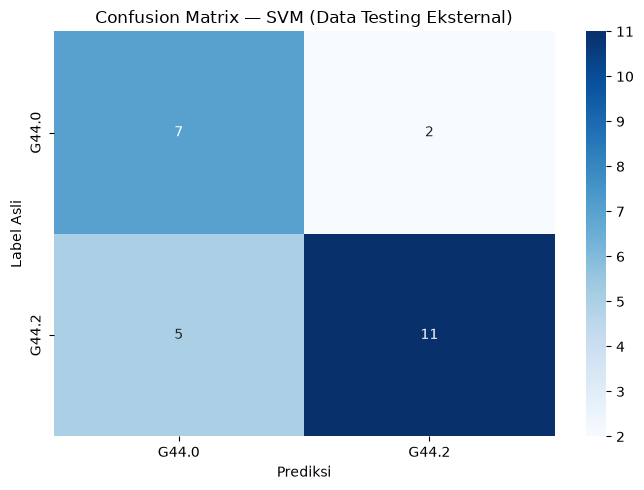

In [33]:
# ─────────────────────────────────────────────────────────────
# 18.3  Evaluasi metrik SVM pada data testing
# ─────────────────────────────────────────────────────────────
acc_svm_ext  = accuracy_score(y_true_ext, y_pred_svm_ext)
f1_svm_ext   = f1_score(y_true_ext, y_pred_svm_ext, average='weighted', zero_division=0)
prec_svm_ext = precision_score(y_true_ext, y_pred_svm_ext, average='weighted', zero_division=0)
rec_svm_ext  = recall_score(y_true_ext, y_pred_svm_ext, average='weighted', zero_division=0)

n_benar_svm = (df_svm_result['status'] == 'BENAR').sum()

print("=" * 55)
print("   EVALUASI SVM — DATA TESTING EKSTERNAL")
print("=" * 55)
print(f"  Model          : SVM linear (dilatih dari data augmented)")
print(f"  Jumlah kasus   : {len(df_test)}")
print(f"  Benar          : {n_benar_svm}")
print(f"  Salah          : {len(df_test) - n_benar_svm}")
print(f"  Accuracy       : {acc_svm_ext:.4f}")
print(f"  F1-Score (W)   : {f1_svm_ext:.4f}")
print(f"  Precision (W)  : {prec_svm_ext:.4f}")
print(f"  Recall (W)     : {rec_svm_ext:.4f}")
print("=" * 55)

print("\n--- Classification Report SVM (Testing) ---")
classes_ext = sorted(df_test['icd_x'].unique())
print(classification_report(y_true_ext, y_pred_svm_ext,
                             labels=classes_ext, zero_division=0))

# Confusion Matrix
cm_svm_ext = confusion_matrix(y_true_ext, y_pred_svm_ext, labels=classes_ext)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm_ext, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_ext, yticklabels=classes_ext)
plt.title('Confusion Matrix — SVM (Data Testing Eksternal)')
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.tight_layout()
plt.show()

## Langkah 19: Testing dengan Metode CBR

Menggunakan **CBR Cosine Similarity** dengan basis kasus augmented (200 kasus) untuk memprediksi label tiap kasus testing.

- Threshold  : **≥ 0.70**
- Strategi   : Weighted majority voting dari top-5 kasus terdekat
- Catatan    : Data testing adalah data **eksternal** sehingga seluruh 200 kasus augmented digunakan sebagai basis kasus (tidak perlu LOO).

In [34]:
# ─────────────────────────────────────────────────────────────
# 19.1  Jalankan CBR untuk setiap kasus testing
# ─────────────────────────────────────────────────────────────
print("=== Pengujian CBR pada Data Testing Eksternal ===")
print(f"Basis kasus  : {len(df_cbr)} kasus (data augmented)")
print(f"Threshold    : {THRESHOLD_SIMILARITY}")
print(f"Kasus diuji  : {len(df_test)} kasus")
print("Memproses...\n")

cbr_test_results = []

for i, row in df_test.iterrows():
    query_text = row['normalized_semicolon']
    true_label = row['icd_x']

    # Gunakan SELURUH basis kasus augmented (tidak perlu LOO untuk data testing eksternal)
    hasil_i = cbr_predict(
        query_text      = query_text,
        case_base_tfidf = case_base_matrix,
        df_cases        = df_cbr,
        vectorizer      = cbr_vectorizer,
        threshold       = THRESHOLD_SIMILARITY,
        top_k           = 5
    )

    pred_label  = hasil_i['prediksi']
    confidence  = hasil_i['confidence']
    n_retrieved = len(hasil_i['kasus_mirip'])
    best_sim    = float(hasil_i['kasus_mirip']['similarity'].max()) if n_retrieved > 0 else 0.0

    cbr_test_results.append({
        'no'          : i + 1,
        'label_asli'  : true_label,
        'prediksi_cbr': pred_label if pred_label else 'TIDAK_TERJAWAB',
        'confidence'  : confidence,
        'best_sim'    : round(best_sim, 4),
        'n_retrieved' : n_retrieved,
        'status'      : ('BENAR'          if pred_label == true_label else
                         ('TIDAK_TERJAWAB' if pred_label is None       else 'SALAH'))
    })

df_cbr_test = pd.DataFrame(cbr_test_results).set_index('no')
df_cbr_test.index.name = 'No'

print("=== Hasil Prediksi CBR per Kasus ===")
display(df_cbr_test)

=== Pengujian CBR pada Data Testing Eksternal ===
Basis kasus  : 200 kasus (data augmented)
Threshold    : 0.7
Kasus diuji  : 25 kasus
Memproses...

=== Hasil Prediksi CBR per Kasus ===


,label_asli,prediksi_cbr,confidence,best_sim,n_retrieved,status
No,,,,,,
1,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
2,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
3,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
4,G44.0,G44.0,1.0,1.0000,5,BENAR
5,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
6,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
7,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
8,G44.0,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
9,G44.0,G44.0,1.0,0.8978,3,BENAR


   EVALUASI CBR — DATA TESTING EKSTERNAL
  Basis kasus     : 200 kasus (data augmented)
  Threshold       : 0.7
  Jumlah kasus    : 25
  Terjawab        : 2 (8.0%)
  Tidak terjawab  : 23 (92.0%)
  Benar           : 2
  Salah           : 0

  ── Metrik (semua kasus) ──────────────────────
  Accuracy (Overall)    : 0.0800
  Coverage              : 0.0800

  ── Metrik (kasus terjawab saja) ──────────────
  Accuracy (Conditional): 1.0000
  F1-Score (W)          : 1.0000
  Precision (W)         : 1.0000
  Recall (W)            : 1.0000
  Avg Confidence        : 1.0000
  Avg Best Similarity   : 0.9489

--- Classification Report CBR (Testing, Kasus Terjawab) ---
              precision    recall  f1-score   support

       G44.0       1.00      1.00      1.00         2
       G44.2       0.00      0.00      0.00         0

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



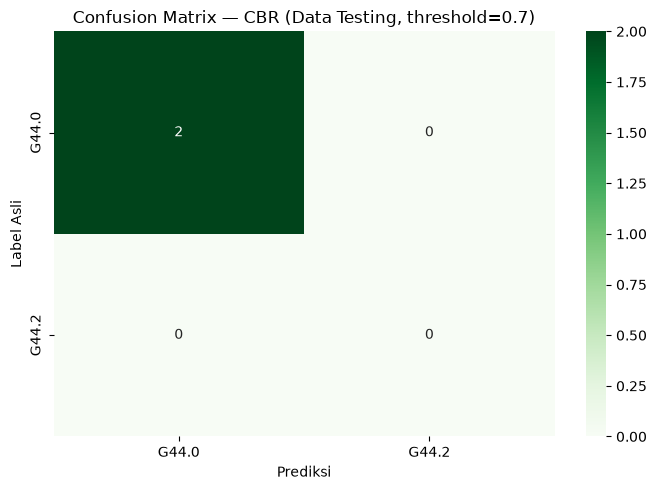

In [35]:
# ─────────────────────────────────────────────────────────────
# 19.2  Evaluasi metrik CBR pada data testing
# ─────────────────────────────────────────────────────────────
df_cbr_terjawab = df_cbr_test[df_cbr_test['prediksi_cbr'] != 'TIDAK_TERJAWAB']
df_cbr_tidak    = df_cbr_test[df_cbr_test['prediksi_cbr'] == 'TIDAK_TERJAWAB']

n_total_t    = len(df_test)
n_terjawab_t = len(df_cbr_terjawab)
n_tidak_t    = len(df_cbr_tidak)
n_benar_cbr  = (df_cbr_test['status'] == 'BENAR').sum()
n_salah_cbr  = (df_cbr_test['status'] == 'SALAH').sum()

coverage_t      = n_terjawab_t / n_total_t
acc_cbr_overall = n_benar_cbr / n_total_t
acc_cbr_cond    = n_benar_cbr / n_terjawab_t if n_terjawab_t > 0 else 0.0

y_true_cbr_t = df_cbr_terjawab['label_asli'].tolist()
y_pred_cbr_t = df_cbr_terjawab['prediksi_cbr'].tolist()

f1_cbr_t   = f1_score(y_true_cbr_t, y_pred_cbr_t, average='weighted', zero_division=0)        if n_terjawab_t > 0 else 0.0
prec_cbr_t = precision_score(y_true_cbr_t, y_pred_cbr_t, average='weighted', zero_division=0) if n_terjawab_t > 0 else 0.0
rec_cbr_t  = recall_score(y_true_cbr_t, y_pred_cbr_t, average='weighted', zero_division=0)    if n_terjawab_t > 0 else 0.0

print("=" * 58)
print("   EVALUASI CBR — DATA TESTING EKSTERNAL")
print("=" * 58)
print(f"  Basis kasus     : {len(df_cbr)} kasus (data augmented)")
print(f"  Threshold       : {THRESHOLD_SIMILARITY}")
print(f"  Jumlah kasus    : {n_total_t}")
print(f"  Terjawab        : {n_terjawab_t} ({coverage_t:.1%})")
print(f"  Tidak terjawab  : {n_tidak_t} ({(1-coverage_t):.1%})")
print(f"  Benar           : {n_benar_cbr}")
print(f"  Salah           : {n_salah_cbr}")
print()
print(f"  ── Metrik (semua kasus) ──────────────────────")
print(f"  Accuracy (Overall)    : {acc_cbr_overall:.4f}")
print(f"  Coverage              : {coverage_t:.4f}")
print()
print(f"  ── Metrik (kasus terjawab saja) ──────────────")
print(f"  Accuracy (Conditional): {acc_cbr_cond:.4f}")
print(f"  F1-Score (W)          : {f1_cbr_t:.4f}")
print(f"  Precision (W)         : {prec_cbr_t:.4f}")
print(f"  Recall (W)            : {rec_cbr_t:.4f}")
print(f"  Avg Confidence        : {df_cbr_terjawab['confidence'].mean() if n_terjawab_t > 0 else 0.0:.4f}")
print(f"  Avg Best Similarity   : {df_cbr_terjawab['best_sim'].mean() if n_terjawab_t > 0 else 0.0:.4f}")
print("=" * 58)

if n_terjawab_t > 0:
    print("\n--- Classification Report CBR (Testing, Kasus Terjawab) ---")
    print(classification_report(y_true_cbr_t, y_pred_cbr_t,
                                 labels=classes_ext, zero_division=0))

    cm_cbr_ext = confusion_matrix(y_true_cbr_t, y_pred_cbr_t, labels=classes_ext)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_cbr_ext, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes_ext, yticklabels=classes_ext)
    plt.title(f'Confusion Matrix — CBR (Data Testing, threshold={THRESHOLD_SIMILARITY})')
    plt.xlabel('Prediksi')
    plt.ylabel('Label Asli')
    plt.tight_layout()
    plt.show()

In [36]:
# ─────────────────────────────────────────────────────────────
# 19.3  Detail kasus yang TIDAK TERJAWAB oleh CBR
# ─────────────────────────────────────────────────────────────
print(f"=== Detail Kasus TIDAK TERJAWAB oleh CBR ===")
print(f"(Max cosine similarity < {THRESHOLD_SIMILARITY})\n")

if n_tidak_t > 0:
    idx_tidak = df_cbr_test[df_cbr_test['prediksi_cbr'] == 'TIDAK_TERJAWAB'].index.tolist()
    df_tidak_detail = df_test.iloc[[i - 1 for i in idx_tidak]][['icd_x', 'normalized_semicolon']].copy()
    df_tidak_detail.index = idx_tidak
    df_tidak_detail.index.name = 'No'
    df_tidak_detail.columns = ['label_asli', 'gejala']
    df_tidak_detail['best_sim'] = [df_cbr_test.loc[i, 'best_sim'] for i in idx_tidak]
    display(df_tidak_detail)
else:
    print("Semua kasus testing berhasil dijawab oleh CBR!")

=== Detail Kasus TIDAK TERJAWAB oleh CBR ===
(Max cosine similarity < 0.7)



,label_asli,gejala,best_sim
No,,,
1,G44.0,konsultasi rujukan;hidung masih mampet;pusing;...,0.0
2,G44.0,Pusing berputar;mual;muntah saat pusing;sejak ...,0.0
3,G44.0,nyeri kepala;badan meriang;mual;sejak 2 hari;a...,0.0
5,G44.0,Pusing;terasa tidak nyaman di badan;tengkuk te...,0.0
6,G44.0,"tengkuk terasa kaku, tegang;resume dari RS Sar...",0.0
7,G44.0,pusing di daerah dahi sekitar mata;dan pusing ...,0.0
8,G44.0,nyeri kepala berdenyut;2 bulan;bengkak telinga...,0.0
10,G44.2,tengkuk terasa kenceng kenceng;pusing,0.0
11,G44.2,pusing;jantung berdebar;kadang ulu hati nyeri ...,0.0


## Langkah 20: Perbandingan Akhir — SVM vs CBR pada Data Testing

Ringkasan perbandingan akhir antara SVM dan CBR pada **data testing eksternal**.

=== Perbandingan Akhir: SVM vs CBR — Data Testing Eksternal ===
                      SVM (Augmented → Testing)  CBR Overall  CBR Conditional
Metrik                                                                       
Accuracy                                 0.7200       0.0800           1.0000
F1-Score (Weighted)                      0.7255       1.0000           1.0000
Precision (Weighted)                     0.7515       1.0000           1.0000
Recall (Weighted)                        0.7200       1.0000           1.0000

* CBR Threshold   : 0.7
* CBR Coverage    : 0.0800 (8.0% kasus terjawab dari 25)


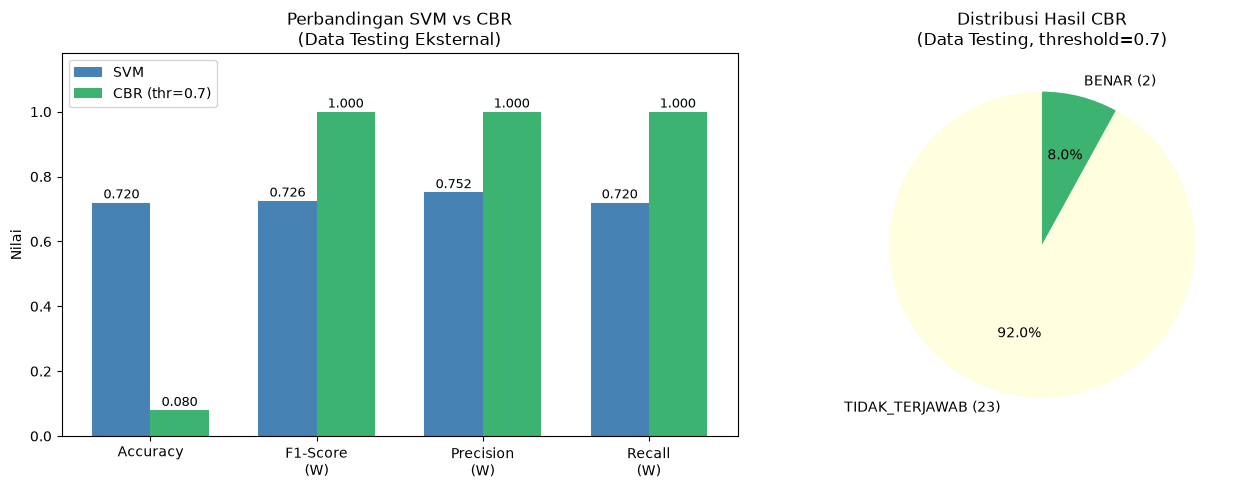

In [37]:
# ─────────────────────────────────────────────────────────────
# Tabel perbandingan akhir SVM vs CBR pada data testing
# ─────────────────────────────────────────────────────────────
df_final_cmp = pd.DataFrame({
    'Metrik'                       : ['Accuracy', 'F1-Score (Weighted)',
                                       'Precision (Weighted)', 'Recall (Weighted)'],
    'SVM (Augmented → Testing)'    : [acc_svm_ext,     f1_svm_ext,  prec_svm_ext,  rec_svm_ext],
    'CBR Overall'                  : [acc_cbr_overall, f1_cbr_t,    prec_cbr_t,    rec_cbr_t],
    'CBR Conditional'              : [acc_cbr_cond,    f1_cbr_t,    prec_cbr_t,    rec_cbr_t],
}).set_index('Metrik')

print("=== Perbandingan Akhir: SVM vs CBR — Data Testing Eksternal ===")
print(df_final_cmp.to_string(float_format='{:.4f}'.format))
print(f"\n* CBR Threshold   : {THRESHOLD_SIMILARITY}")
print(f"* CBR Coverage    : {coverage_t:.4f} ({coverage_t:.1%} kasus terjawab dari {n_total_t})")

# ── Visualisasi bar chart + pie chart ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: SVM vs CBR ---
metrik_lbl = ['Accuracy', 'F1-Score\n(W)', 'Precision\n(W)', 'Recall\n(W)']
v_svm = [acc_svm_ext,     f1_svm_ext,  prec_svm_ext,  rec_svm_ext]
v_cbr = [acc_cbr_overall, f1_cbr_t,    prec_cbr_t,    rec_cbr_t]

x_pos = np.arange(len(metrik_lbl))
w = 0.35
b1 = axes[0].bar(x_pos - w/2, v_svm, w, label='SVM', color='steelblue')
b2 = axes[0].bar(x_pos + w/2, v_cbr, w,
                 label=f'CBR (thr={THRESHOLD_SIMILARITY})', color='mediumseagreen')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrik_lbl)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel('Nilai')
axes[0].set_title('Perbandingan SVM vs CBR\n(Data Testing Eksternal)')
axes[0].legend()
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].annotate(f'{h:.3f}',
                         xy=(bar.get_x() + bar.get_width()/2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', fontsize=9)

# --- Pie chart: Distribusi status CBR ---
status_cbr_ext = df_cbr_test['status'].value_counts()
color_map = {'BENAR': 'mediumseagreen', 'SALAH': 'lightcoral', 'TIDAK_TERJAWAB': 'lightyellow'}
pie_colors = [color_map.get(s, 'grey') for s in status_cbr_ext.index]
axes[1].pie(status_cbr_ext.values,
            labels=[f'{s} ({v})' for s, v in zip(status_cbr_ext.index, status_cbr_ext.values)],
            colors=pie_colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title(f'Distribusi Hasil CBR\n(Data Testing, threshold={THRESHOLD_SIMILARITY})')

plt.tight_layout()
plt.show()

## Langkah 20: Ekspor Hasil Testing ke File CSV

Menyimpan seluruh detail prediksi dari model **SVM** dan **CBR** pada data testing eksternal ke file `hasil_testing.csv`.

In [38]:
# ─────────────────────────────────────────────────────────────
# Ekspor Hasil Prediksi SVM dan CBR ke CSV
# ─────────────────────────────────────────────────────────────
PATH_HASIL_TESTING = os.path.join(DATASET_DIR, 'hasil_testing.csv')

df_hasil_testing = pd.DataFrame({
    'No': range(1, len(df_test) + 1),
    'label_asli': df_test['icd_x'],
    'gejala': df_test['normalized_semicolon'],
    'prediksi_svm': df_svm_result['prediksi_svm'].values,
    'status_svm': df_svm_result['status'].values,
    'prediksi_cbr': df_cbr_test['prediksi_cbr'].values,
    'confidence_cbr': df_cbr_test['confidence'].values,
    'best_sim_cbr': df_cbr_test['best_sim'].values,
    'n_retrieved_cbr': df_cbr_test['n_retrieved'].values,
    'status_cbr': df_cbr_test['status'].values
})

# Simpan ke file CSV
df_hasil_testing.to_csv(PATH_HASIL_TESTING, index=False)

print("=" * 60)
print("HASIL TESTING BERHASIL DISIMPAN!")
print(f"File CSV disimpan ke : {os.path.abspath(PATH_HASIL_TESTING)}")
print(f"Jumlah baris         : {len(df_hasil_testing)}")
print("=" * 60)

print("\n--- Pratinjau Hasil Testing ---")
display(df_hasil_testing)


HASIL TESTING BERHASIL DISIMPAN!
File CSV disimpan ke : c:\Users\admin\Documents\Penelitian\CBR Research\Dataset\hasil_testing.csv
Jumlah baris         : 25

--- Pratinjau Hasil Testing ---


,No,label_asli,gejala,prediksi_svm,status_svm,prediksi_cbr,confidence_cbr,best_sim_cbr,n_retrieved_cbr,status_cbr
0,1,G44.0,konsultasi rujukan;hidung masih mampet;pusing;...,G44.0,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
1,2,G44.0,Pusing berputar;mual;muntah saat pusing;sejak ...,G44.0,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
2,3,G44.0,nyeri kepala;badan meriang;mual;sejak 2 hari;a...,G44.0,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
3,4,G44.0,pusing sebelah kiri;sejak kemarin;tengkuk bahu...,G44.0,BENAR,G44.0,1.0,1.0000,5,BENAR
4,5,G44.0,Pusing;terasa tidak nyaman di badan;tengkuk te...,G44.2,SALAH,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
5,6,G44.0,"tengkuk terasa kaku, tegang;resume dari RS Sar...",G44.0,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
6,7,G44.0,pusing di daerah dahi sekitar mata;dan pusing ...,G44.2,SALAH,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
7,8,G44.0,nyeri kepala berdenyut;2 bulan;bengkak telinga...,G44.0,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
8,9,G44.0,Mata kiri terasa nyeri;kemerahan nihil;penglih...,G44.0,BENAR,G44.0,1.0,0.8978,3,BENAR
9,10,G44.2,tengkuk terasa kenceng kenceng;pusing,G44.2,BENAR,TIDAK_TERJAWAB,0.0,0.0000,0,TIDAK_TERJAWAB
